In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython.display import Audio, display
from dct_utils import (
    bark_bands, compress_dct_psycho, compute_snr,
    log_spectral_distance, encode_psycho_huffman, decode_psycho_huffman, encode_psycho_huffman_plus
)
import soundfile as sf

sig, sr = librosa.load("samples/scotland.wav", sr=None, mono=True)
sig = sig / (np.max(np.abs(sig)) + 1e-12)

frame_size   = 256
ratio        = 0.25
k            = int(frame_size * ratio)
spreading_db = 36

print(f"sr={sr}Hz  długość={len(sig)/sr:.1f}s")
print(f"frame={frame_size}  k={k}  ratio={ratio*100:.0f}%")

sr=48000Hz  długość=80.5s
frame=256  k=64  ratio=25%


## Huffman
Liczy ile razy każda wartość wystąpuje w danych.
Częste wartości → krótki kod binarny, rzadkie → długi.
Zero pojawia się najczęściej po kwantyzacji DCT, dostaje 1 bit zamiast 8.

## Test 1 — Huffman int16
1. Zakres int16 to -32767..32767 — słownik ma tysiące symboli.
2. Sam słownik zajął więcej miejsca niż zysk z kodowania.
3. Wynik: 8835 KB zamiast 3773 KB raw — Huffman powiększył plik.

## Test 2 — Huffman int8 + dead zone
1. Ograniczono zakres do -63..63, słownik max 127 symboli.
2. Dead zone zeruje małe wartości przed kodowaniem — więcej zer = lepszy Huffman.
3. Wynik: 5375 KB, ale SNR=0 dB przez błąd dekodera niekompatybilnego z nowym formatem.

## Co dalej
1. Predefiniowane tablice — MP3 ma 32 wbudowane tablice Huffmana w standardzie ISO,
   dekoder je zna bez zapisywania do pliku, narzut = zero.
2. Maska bitowa zamiast indeksów — zastąpienie listy indeksów uint16 maską bitową
   redukuje narzut o 75% przy małym k.

PCM oryginał:       15094 KB
psycho int16 (raw): 3773 KB
psycho + Huffman:   8835 KB
kompresja vs PCM:   1.7x
SNR:                29.5 dB
LSD:                36.2
Zapisano: compressed_v1.bin  +  decoded_v1.wav


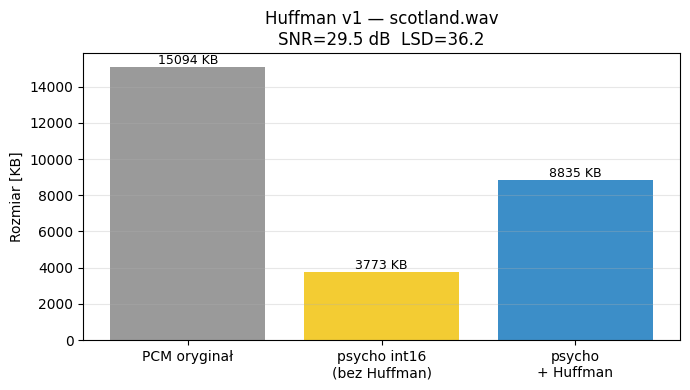

In [2]:
size_kb = encode_psycho_huffman(sig, sr, frame_size, k,
                                 spreading_db=spreading_db,
                                 bits=16, path="compressed_v1.bin")
rec     = decode_psycho_huffman("compressed_v1.bin")
snr     = compute_snr(sig, rec)
lsd     = log_spectral_distance(sig, rec, sr)
pcm_kb  = len(sig) * 4 / 1024
raw_kb  = k * 2 * ((len(sig) - frame_size) // (frame_size // 2)) / 1024

sf.write("decoded_v1.wav", rec, sr)

print(f"PCM oryginał:       {pcm_kb:.0f} KB")
print(f"psycho int16 (raw): {raw_kb:.0f} KB")
print(f"psycho + Huffman:   {size_kb:.0f} KB")
print(f"kompresja vs PCM:   {pcm_kb/size_kb:.1f}x")
print(f"SNR:                {snr:.1f} dB")
print(f"LSD:                {lsd:.1f}")
print(f"Zapisano: compressed_v1.bin  +  decoded_v1.wav")

fig, ax = plt.subplots(figsize=(7, 4))
names  = ["PCM oryginał", "psycho int16\n(bez Huffman)", "psycho\n+ Huffman"]
sizes  = [pcm_kb, raw_kb, size_kb]
colors = ['#888888', '#f1c40f', '#1a7abf']
bars   = ax.bar(names, sizes, color=colors, alpha=0.85)
for bar, v in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width() / 2, v + pcm_kb * 0.01,
            f"{v:.0f} KB", ha='center', fontsize=9)
ax.set_ylabel("Rozmiar [KB]")
ax.set_title(f"Huffman v1 — scotland.wav\nSNR={snr:.1f} dB  LSD={lsd:.1f}")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

PCM oryginał:       15094 KB
psycho int16 (raw): 3773 KB
psycho + Huffman:   5375 KB
kompresja vs PCM:   2.8x
SNR:                5.9 dB
LSD:                40.8
Zapisano: compressed_v2.bin  +  decoded_v2.wav


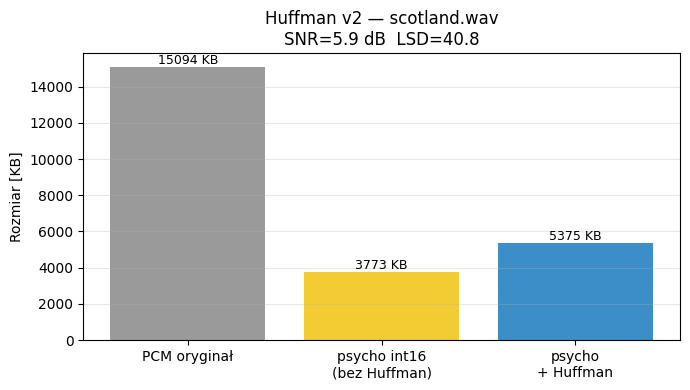

In [3]:
size_kb = encode_psycho_huffman_plus(sig, sr, frame_size, k,
                                      spreading_db=spreading_db,
                                      bits=8, path="compressed_v2.bin")
rec     = decode_psycho_huffman("compressed_v2.bin")
snr     = compute_snr(sig, rec)
lsd     = log_spectral_distance(sig, rec, sr)

sf.write("decoded_v2.wav", rec, sr)

print(f"PCM oryginał:       {pcm_kb:.0f} KB")
print(f"psycho int16 (raw): {raw_kb:.0f} KB")
print(f"psycho + Huffman:   {size_kb:.0f} KB")
print(f"kompresja vs PCM:   {pcm_kb/size_kb:.1f}x")
print(f"SNR:                {snr:.1f} dB")
print(f"LSD:                {lsd:.1f}")
print(f"Zapisano: compressed_v2.bin  +  decoded_v2.wav")

fig, ax = plt.subplots(figsize=(7, 4))
bars   = ax.bar(names, [pcm_kb, raw_kb, size_kb], color=colors, alpha=0.85)
for bar, v in zip(bars, [pcm_kb, raw_kb, size_kb]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + pcm_kb * 0.01,
            f"{v:.0f} KB", ha='center', fontsize=9)
ax.set_ylabel("Rozmiar [KB]")
ax.set_title(f"Huffman v2 — scotland.wav\nSNR={snr:.1f} dB  LSD={lsd:.1f}")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()